# **ANÁLISIS EXPLORATORIO DE DATOS (EDA)**

In [ ]:
# Procesamiento de datos
import pandas as pd
import numpy as np
import datetime
import math
from statsmodels.tsa.stattools import adfuller
# Importación de datos financieros
import yfinance as yf
# Gráficos
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.figure_factory as ff
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Medidas del error
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

In [ ]:
# Función Test Dickey-Fuller
def Dickey_Fuller_Test(serie, column_name):
  dftest = adfuller(serie, autolag='AIC')
  dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','Num Lags Used','Num Obs Used'])
  print(dfoutput)
  if dftest[1] <= 0.05:
    print('Conclusión: Rechazar la hipótesis nula (p-value <= 0.05)')
    print('Los datos son estacionarios')
  else:
    print('Conclusión: No se puede rechazar la hipótesis nula (p-value >= 0.05)')
    print('Los datos no son estacionarios')

## Parámetros estadísticos

In [ ]:
# Recopilamos los datos de Yahoo Finance
empresas = [
    'TSLA', #Tesla
    'GOOG', #Google
    'META', #Meta
    'AMZN', #Amazon
    'MSFT', #Microsoft
    'AAPL', #Apple
]
lista = []
# Definimos las fechas de inicio y finalización
start_date = datetime.datetime(2012, 5, 18)
end_date = datetime.datetime(2023, 9, 30)
for emp in empresas:
    ticker = yf.Ticker(emp) # Descarga los datos históricos de la empresa (Open, Max, Min, Close, Adj Close, Volume)
    dat = ticker.history(start = start_date, end = end_date)['Close'] # Seleccionamos los datos de precio de cierre (Close) en el rango de fechas definido
    dat.name = emp # Llamamos a la columna creada como el nombre de la empresa
    lista += [dat]
data = pd.concat(lista, axis=1)
print(data.head())
data.describe()

                               TSLA       GOOG       META     AMZN       MSFT  \
Date                                                                            
2012-05-18 00:00:00-04:00  1.837333  14.953949  38.230000  10.6925  23.571972   
2012-05-21 00:00:00-04:00  1.918000  15.295419  34.029999  10.9055  23.958525   
2012-05-22 00:00:00-04:00  2.053333  14.963912  31.000000  10.7665  23.966585   
2012-05-23 00:00:00-04:00  2.068000  15.179603  32.000000  10.8640  23.443119   
2012-05-24 00:00:00-04:00  2.018667  15.035145  33.029999  10.7620  23.410900   

                                AAPL  
Date                                  
2012-05-18 00:00:00-04:00  16.056871  
2012-05-21 00:00:00-04:00  16.992340  
2012-05-22 00:00:00-04:00  16.861860  
2012-05-23 00:00:00-04:00  17.273294  
2012-05-24 00:00:00-04:00  17.114658  


,TSLA,GOOG,META,AMZN,MSFT,AAPL
count,2860.000000,2860.000000,2860.000000,2860.000000,2860.000000,2860.000000
mean,78.246013,60.579007,153.993783,73.120767,123.165333,65.061429
std,103.794528,37.409563,88.366206,53.269488,99.063449,54.432332
min,1.740000,13.924059,17.730000,10.411000,21.552860,11.997528
25%,14.088333,28.788835,80.380003,19.782376,39.986420,23.148197
50%,19.263666,51.811001,150.964996,67.361500,83.640720,39.893337
75%,144.024998,87.011627,199.712498,110.457500,210.341949,118.815510
max,409.970001,150.709000,382.179993,186.570496,358.003845,195.926956


In [ ]:
print(data.shape)

(2860, 6)


## Precios de cierre

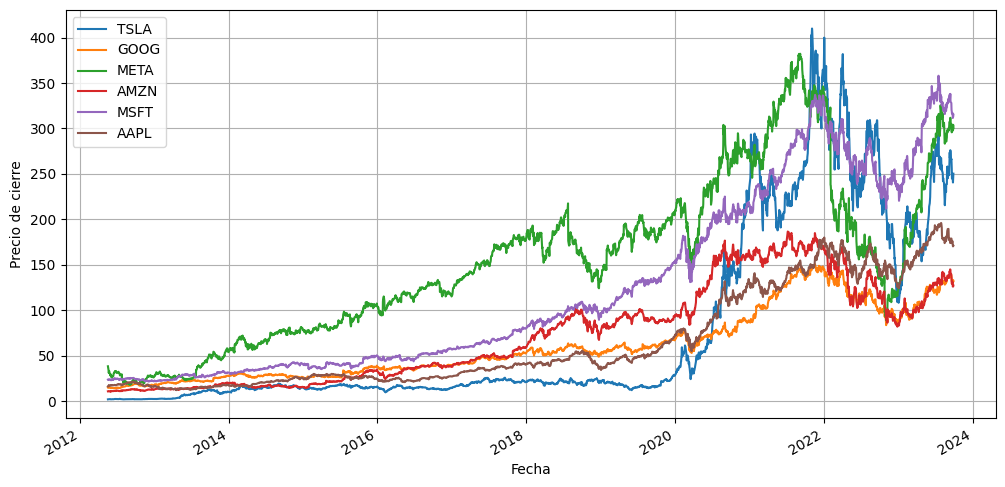

In [ ]:
# Gráfica del precio de cierre de todas las empresas
data.plot(figsize=(12, 6))
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.grid()
plt.legend(empresas)
plt.show()

## Rentabilidad y volatilidad

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


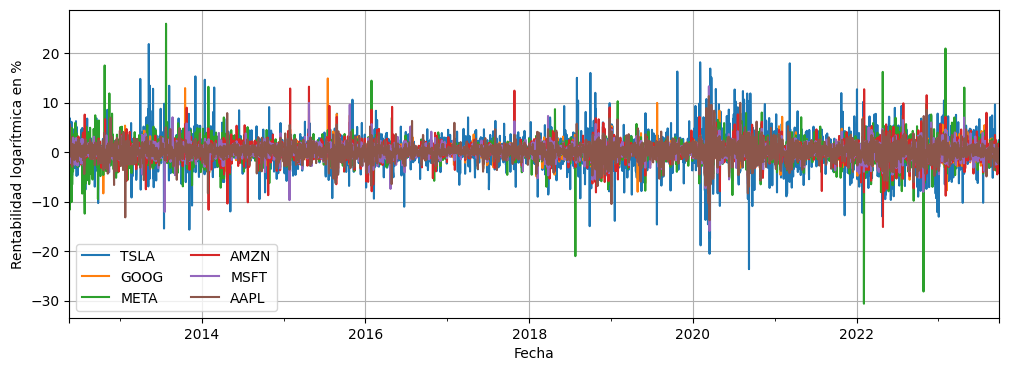

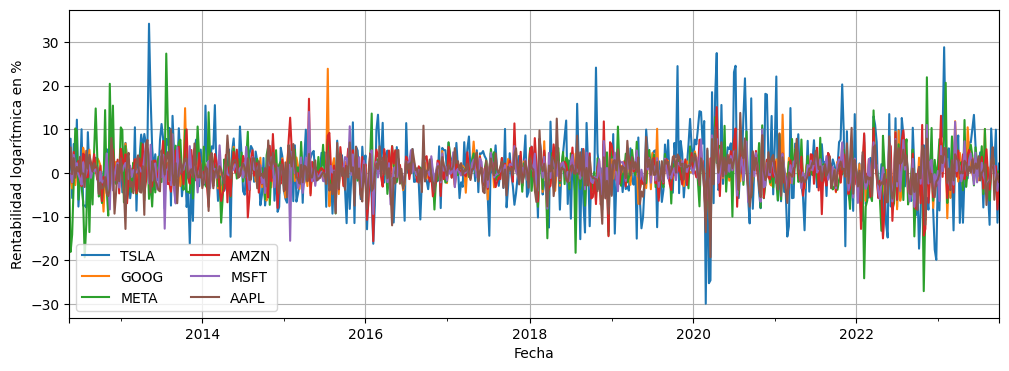

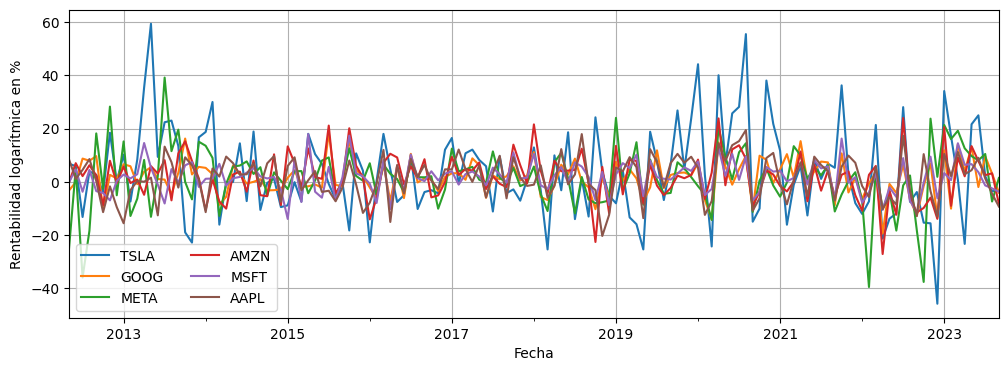

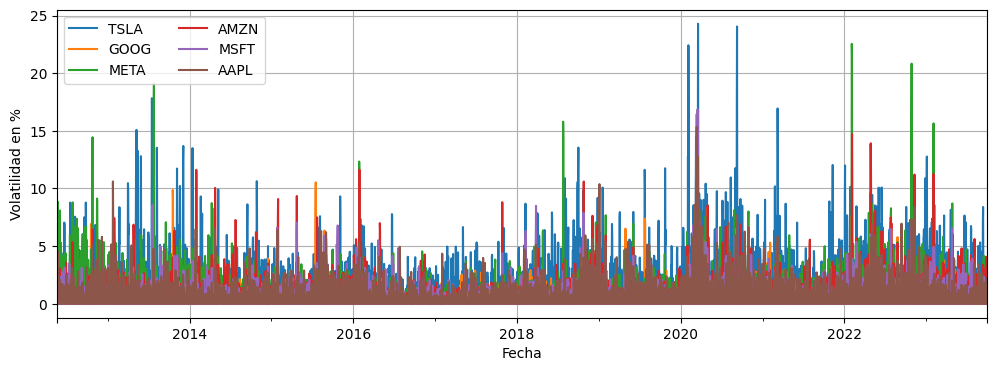

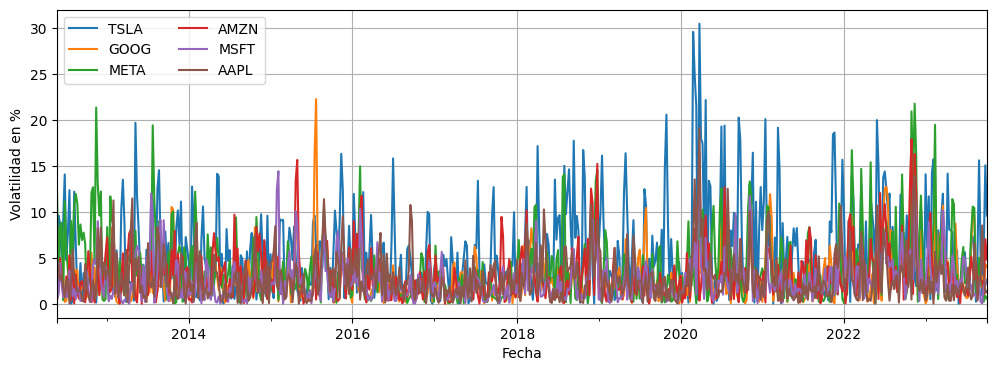

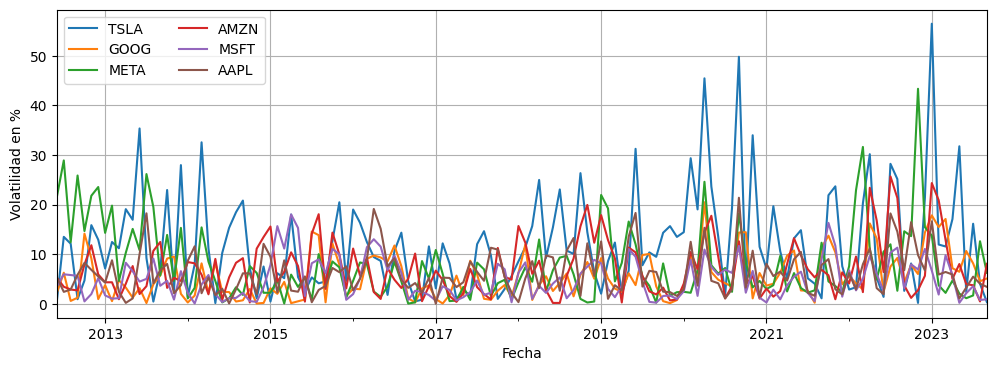

In [ ]:
empresas = [
    'TSLA', #Tesla
    'GOOG', #Google
    'META', #Meta
    'AMZN', #Amazon
    'MSFT', #Microsoft
    'AAPL', #Apple
]
rentabilidad_mensual = pd.DataFrame()
rentabilidad_semanal = pd.DataFrame()
rentabilidad_diaria = pd.DataFrame()
vol_mensual = pd.DataFrame()
vol_semanal = pd.DataFrame()
vol_diaria = pd.DataFrame()
# Recopilamos los datos de Yahoo Finance
for emp in empresas:
  ticker= emp
  data = yf.download(ticker, start="2012-05-18", end="2023-09-30")
  data['R_Log'] = 100*data['Close'].apply(np.log).diff().dropna()
  rent_diaria = data['R_Log'].resample('D').sum() # 'W' --> Week (Semana)
  vol_diaria[emp] = rent_diaria.rolling(window=2).std().dropna()
  rentabilidad_diaria[emp] = rent_diaria
  rent_semanal = data['R_Log'].resample('W').sum() # 'W' --> Week (Semana)
  vol_semanal[emp] = rent_semanal.rolling(window=2).std().dropna()
  rentabilidad_semanal[emp] = rent_semanal
  rent_mensual = data['R_Log'].resample('M').sum() # 'M' --> Month (Mes)
  vol_mensual[emp] = rent_mensual.rolling(window=2).std().dropna()
  rentabilidad_mensual[emp] = rent_mensual
  # Gráfico de la rentabilidad semanal
rentabilidad_diaria.plot(figsize=(12, 4))
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad logarítmica en %')
plt.grid()
plt.legend(empresas, loc='lower left', ncol=2)
plt.show()
# Gráfico de la rentabilidad semanal
rentabilidad_semanal.plot(figsize=(12, 4))
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad logarítmica en %')
plt.grid()
plt.legend(empresas, loc='lower left', ncol=2)
plt.show()
# Gráfico de la rentabilidad mensual
rentabilidad_mensual.plot(figsize=(12, 4))
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad logarítmica en %')
plt.grid()
plt.legend(empresas, loc='lower left', ncol=2)
plt.show()
# Gráfico de la volatilidad diaria
vol_diaria.plot(figsize=(12, 4))
plt.xlabel('Fecha')
plt.ylabel('Volatilidad en %')
plt.grid()
plt.legend(empresas, loc='upper left', ncol=2)
plt.show()
# Gráfico de la volatilidad semanal
vol_semanal.plot(figsize=(12, 4))
plt.xlabel('Fecha')
plt.ylabel('Volatilidad en %')
plt.grid()
plt.legend(empresas, loc='upper left', ncol=2)
plt.show()
# Gráfico de la volatilidad mensual
vol_mensual.plot(figsize=(12, 4))
plt.xlabel('Fecha')
plt.ylabel('Volatilidad en %')
plt.grid()
plt.legend(empresas, loc='upper left', ncol=2)
plt.show()

## Prueba Dickey-Fuller

In [ ]:
import statistics
# Prueba DF para la rentabilidad diaria
print('H0: Los datos no son estacionarios')
print('H1: Los datos son estacionarios')
print(f'\n----- MUESTRAS DIARIAS -----')
for emp in rentabilidad_diaria:
  print(f'\n {emp} \n')
  print('------------------------------')
  Dickey_Fuller_Test(rentabilidad_diaria[emp],emp)
  media = statistics.mean(rentabilidad_diaria[emp])
  print(f'Media:  {media}')
  print('------------------------------')
# Prueba DF para la rentabilidad semanal
print(f'\n----- MUESTRAS SEMANALES -----')
for emp in rentabilidad_semanal:
  print(f'\n {emp} \n')
  print('------------------------------')
  Dickey_Fuller_Test(rentabilidad_semanal[emp],emp)
  media = statistics.mean(rentabilidad_semanal[emp])
  print(f'Media:  {media}')
  print('------------------------------')
  # Prueba DF para la rentabilidad mensual
print(f'\n----- MUESTRAS MENSUALES -----')
for emp in rentabilidad_mensual:
  print(f'\n {emp} \n')
  print('------------------------------')
  Dickey_Fuller_Test(rentabilidad_mensual[emp],emp)
  media = statistics.mean(rentabilidad_mensual[emp])
  print(f'Media:  {media}')
  print('------------------------------')

H0: Los datos no son estacionarios
H1: Los datos son estacionarios

----- MUESTRAS DIARIAS -----

 TSLA 

------------------------------
Test Statistic     -19.560378
p-value              0.000000
Num Lags Used        9.000000
Num Obs Used      4142.000000
dtype: float64
Conclusión: Rechazar la hipótesis nula (p-value <= 0.05)
Los datos son estacionarios
Media:  0.11835321511973199
------------------------------

 GOOG 

------------------------------
Test Statistic   -1.824350e+01
p-value           2.351926e-30
Num Lags Used     1.200000e+01
Num Obs Used      4.139000e+03
dtype: float64
Conclusión: Rechazar la hipótesis nula (p-value <= 0.05)
Los datos son estacionarios
Media:  0.05242508546906084
------------------------------

 META 

------------------------------
Test Statistic     -65.799025
p-value              0.000000
Num Lags Used        0.000000
Num Obs Used      4151.000000
dtype: float64
Conclusión: Rechazar la hipótesis nula (p-value <= 0.05)
Los datos son estacionarios
M

In [ ]:
import statistics
# Prueba DF para la volatilidad diaria
print('H0: Los datos no son estacionarios')
print('H1: Los datos son estacionarios')
print(f'\n----- MUESTRAS DIARIAS -----')
for emp in vol_diaria:
  print(f'\n {emp} \n')
  print('------------------------------')
  Dickey_Fuller_Test(vol_diaria[emp],emp)
  media = statistics.mean(vol_diaria[emp])
  print(f'Media:  {media}')
  print('------------------------------')
# Prueba DF para la volatilidad semanal
print(f'\n----- MUESTRAS SEMANALES -----')
for emp in vol_semanal:
  print(f'\n {emp} \n')
  print('------------------------------')
  Dickey_Fuller_Test(vol_semanal[emp],emp)
  media = statistics.mean(vol_semanal[emp])
  print(f'Media:  {media}')
  print('------------------------------')
  # Prueba DF para la volatilidad mensual
print(f'\n----- MUESTRAS MENSUALES -----')
for emp in vol_mensual:
  print(f'\n {emp} \n')
  print('------------------------------')
  Dickey_Fuller_Test(vol_mensual[emp],emp)
  media = statistics.mean(vol_mensual[emp])
  print(f'Media:  {media}')
  print('------------------------------')

H0: Los datos no son estacionarios
H1: Los datos son estacionarios

----- MUESTRAS DIARIAS -----

 TSLA 

------------------------------
Test Statistic   -8.094763e+00
p-value           1.348334e-12
Num Lags Used     2.900000e+01
Num Obs Used      4.121000e+03
dtype: float64
Conclusión: Rechazar la hipótesis nula (p-value <= 0.05)
Los datos son estacionarios
Media:  1.9262508297630188
------------------------------

 GOOG 

------------------------------
Test Statistic   -7.823870e+00
p-value           6.560250e-12
Num Lags Used     3.100000e+01
Num Obs Used      4.119000e+03
dtype: float64
Conclusión: Rechazar la hipótesis nula (p-value <= 0.05)
Los datos son estacionarios
Media:  0.9079582250810845
------------------------------

 META 

------------------------------
Test Statistic   -7.763297e+00
p-value           9.330240e-12
Num Lags Used     2.700000e+01
Num Obs Used      4.123000e+03
dtype: float64
Conclusión: Rechazar la hipótesis nula (p-value <= 0.05)
Los datos son estaciona

In [ ]:
for emp in empresas[:-5]:
  print(f'Muestras diarias --> {rentabilidad_diaria[emp].shape}')
  print(f'Muestras semanales --> {rentabilidad_semanal[emp].shape}')
  print(f'Muestras mensuales --> {rentabilidad_mensual[emp].shape}')
for emp in empresas[:-5]:
  print(f'Muestras diarias --> {vol_diaria[emp].shape}')
  print(f'Muestras semanales --> {vol_semanal[emp].shape}')
  print(f'Muestras mensuales --> {vol_mensual[emp].shape}')

Muestras diarias --> (4152,)
Muestras semanales --> (594,)
Muestras mensuales --> (137,)
Muestras diarias --> (4151,)
Muestras semanales --> (593,)
Muestras mensuales --> (136,)
